# Matematisk Modellering | Laboration 2 | Martin Andersson & Philip Jönsson

In [44]:
import math
from numpy import random
import numpy as np
import sympy as sy
from matplotlib import pyplot as plt

## Uppgift 1
a)

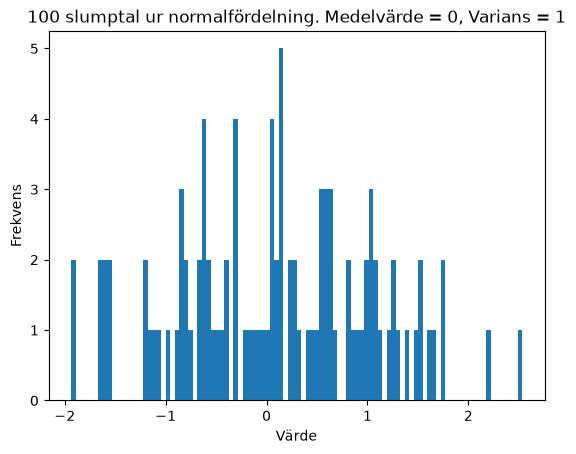

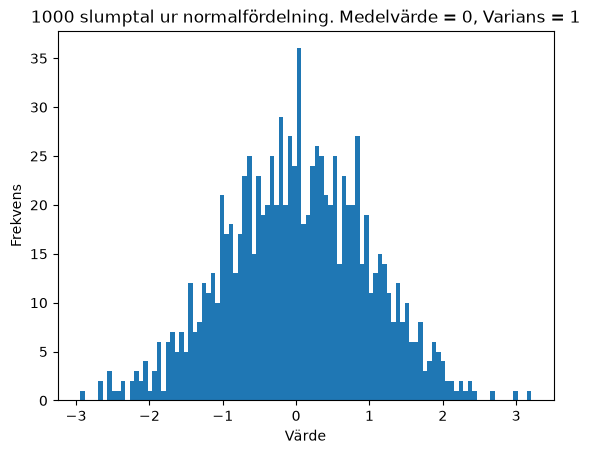

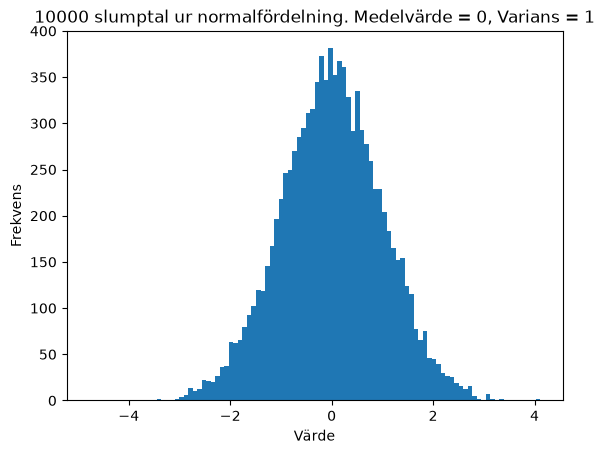

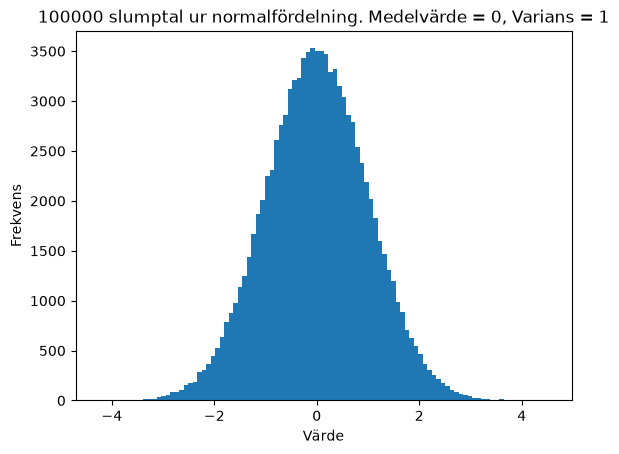

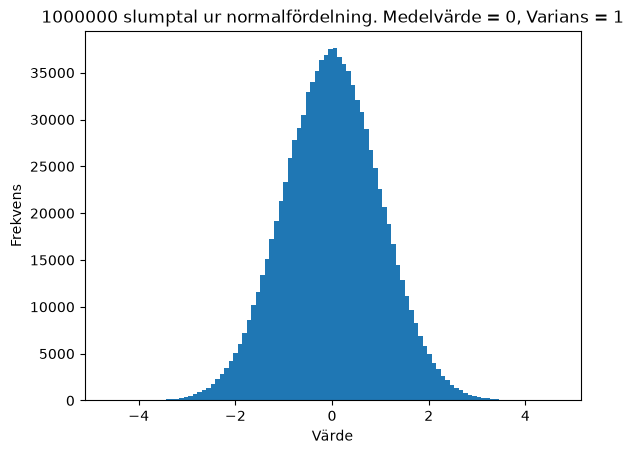

In [45]:
from python_functions import python_normal, python_likform
N_a = 100
while N_a < 1000001:
    python_normal(N_a)
    N_a = N_a*10

## b)

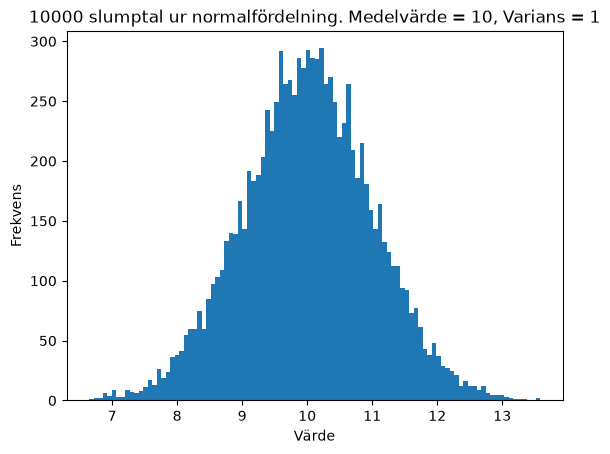

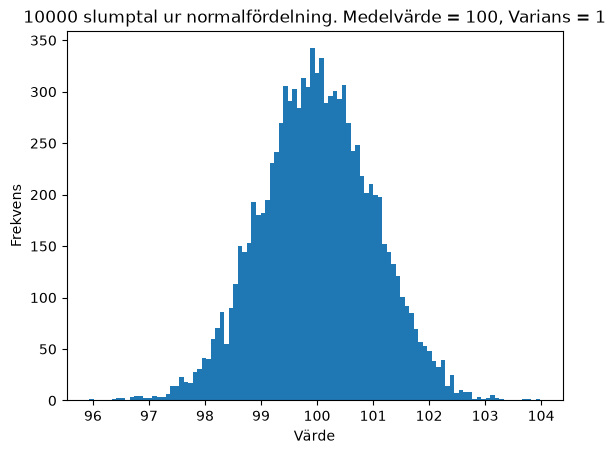

In [46]:
python_normal(10000, 10)
python_normal(10000, 100)

Med samma varians så skiftar endast medelvärdet vart "mitten" av grafen ligger, vilket tydligt kan ses då graferna i huvudsak har lika stora intervall, från 7 - 13 och 97 - 103.

## c)

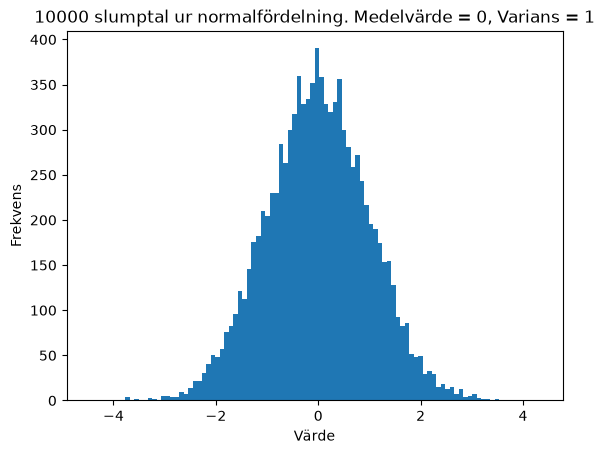

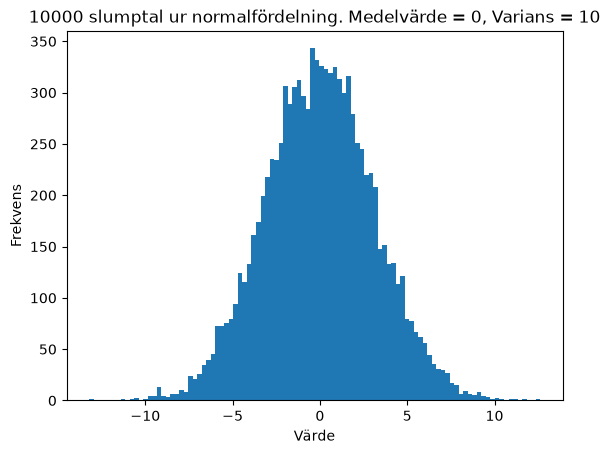

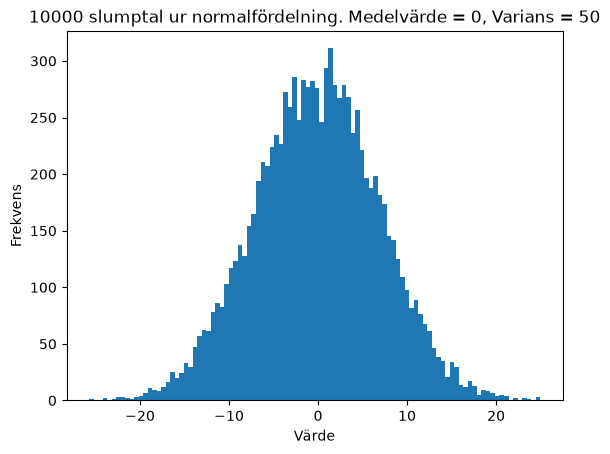

In [47]:
varians_c = [1, 10, 50]
for v in varians_c:
    python_normal (10000, 0, v)

Variansen styr hur brett talen troligen kommer att sprida sig från medelvärdet. Exempelvis så kommer den absoluta majoriteten av talen att befinna sig inom intervallet -10 till 10 med variansen 50, fastän enskilda tal kommer att falla utanför.
## d)

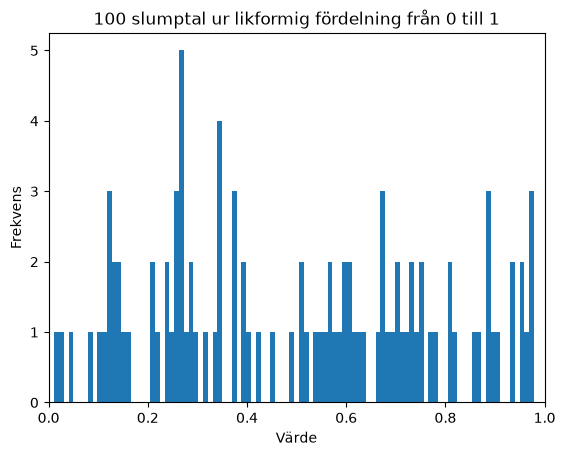

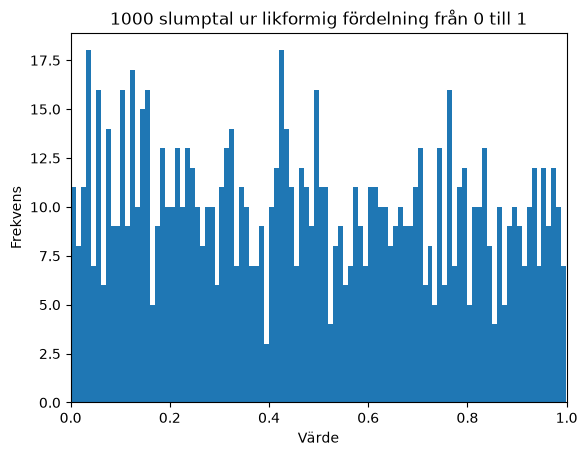

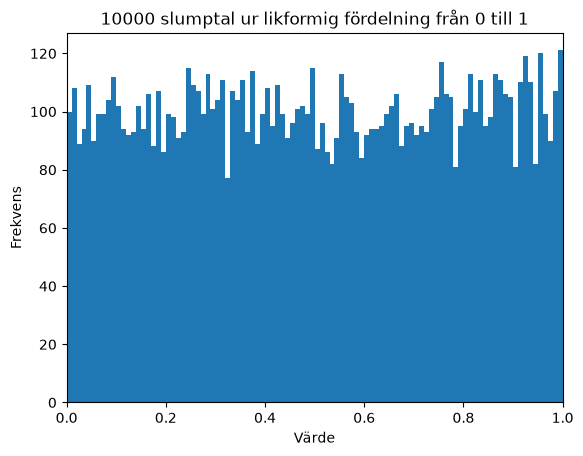

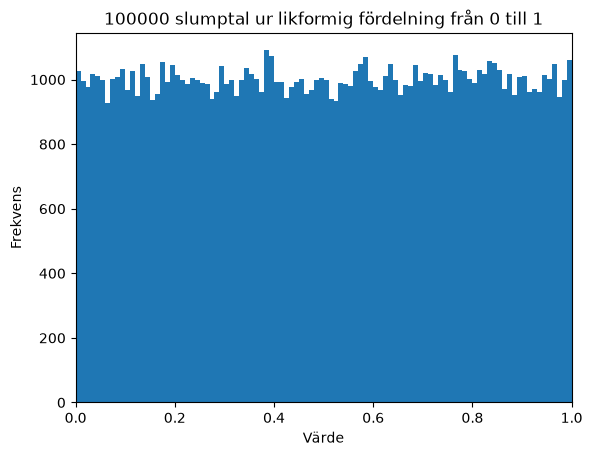

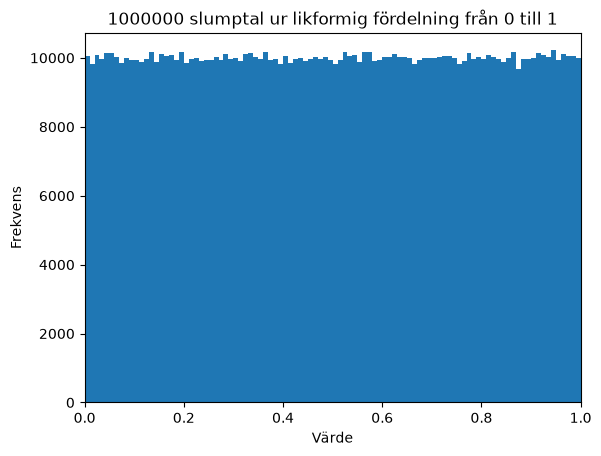

In [48]:
N_d = 100
while N_d < 1000001:
    python_likform (N_d, 0, 1)
    N_d = N_d*10

Graferna belyser att utstickande resultat, som skiljer sig från snittet, väntas förminskas då fler slumptal genereras.
Med 100 slumptal kan det ske att ett värde har drastiskt färre förekomster i mängden än ett annat, men om man skapar fler och fler slumptal så kommer mängden förekomster av varje unikt värde att jämna ut sig.
Man närmar sig snittet för varje variabel, och genererar man flera miljoner slumptal kommer fördelningen att vara ännu mer likformig.
# Uppgift 2
### a)

In [49]:
n= 10**3
y1 = np . floor (1 + 6* random . rand ( n ) )

n=10**4
y2 = np . floor (1 + 6* random . rand ( n ) )

n=10**5
y3 = np . floor (1 + 6* random . rand ( n ) )

medel_y1 = np.mean(y1)
medel_y2 = np.mean(y2)
medel_y3 = np.mean(y3)


print("y1 medel: ", medel_y1, "skillnad från det teoretiska medelvärdet: ", abs(3.5 - medel_y1))
print("y2 medel: ", medel_y2, "skillnad från det teoretiska medelvärdet: ", abs(3.5 - medel_y2))
print("y3 medel: ", medel_y3, "skillnad från det teoretiska medelvärdet: ", abs(3.5 - medel_y3))

y1 medel:  3.5728155339805827 skillnad från det teoretiska medelvärdet:  0.07281553398058271
y2 medel:  3.375 skillnad från det teoretiska medelvärdet:  0.125
y3 medel:  3.54 skillnad från det teoretiska medelvärdet:  0.040000000000000036


Det stämmer, skillnaden blir mindre när talmängden ökas.
### b)

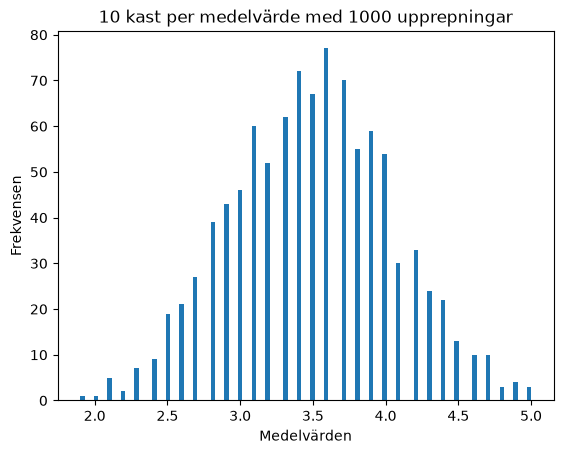

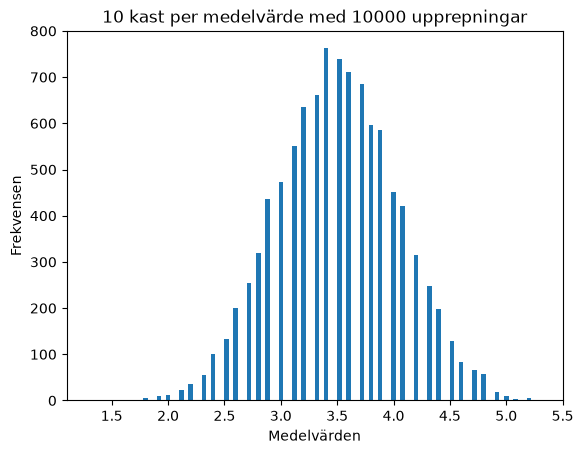

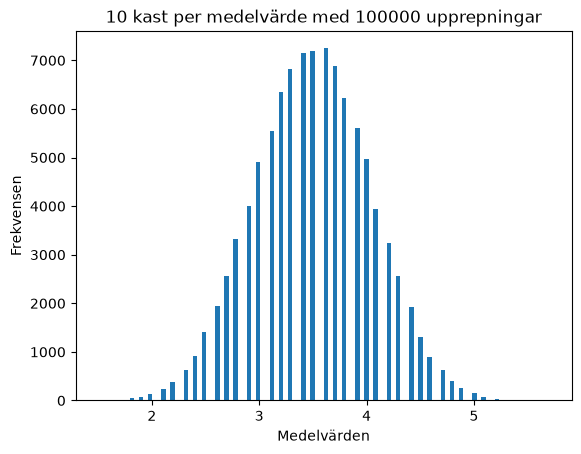

In [50]:
from python_functions import tarning_upprepa

tarning_upprepa ()

Ja, fördelningen närmar sig en normalfördelning då mängden ökas.
### c)

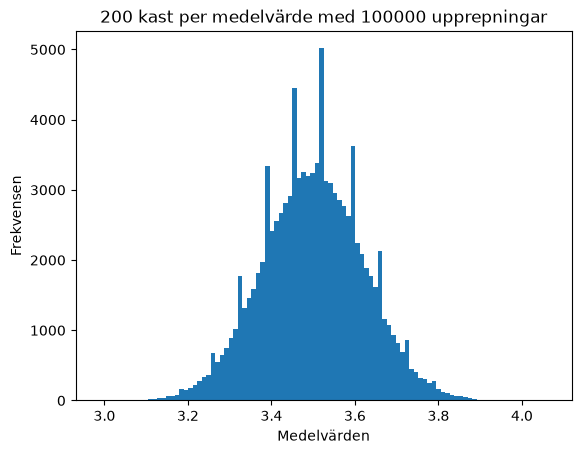

In [61]:
tarning_upprepa (200, [10**5])

En skillnad är att intervallet är mycket mindre, från runt 3 till 4. En till är att vissa värden grupperas ihop när grafen plottas, vilket leder till några enstaka höga staplar i diagrammet.
### d)

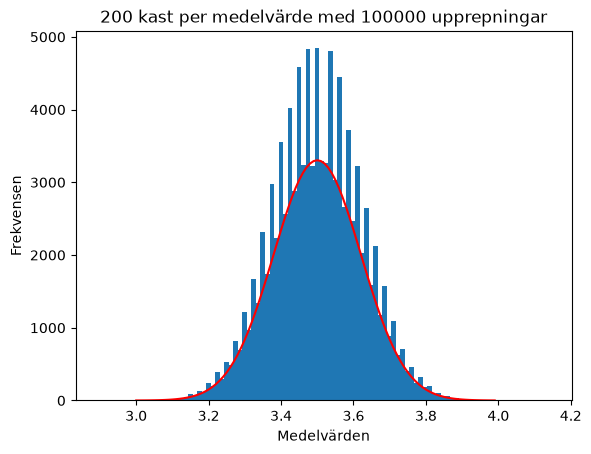

In [64]:
from python_functions import tarning_egen

n = 200
N = 10**5

sigma = np.sqrt(35/(12*n))
mu = 3.5
x = np.arange ( 3 , 4 , 0.01)
f = (1 / (sigma*np.sqrt(2 * np.pi))) * np.exp(-((x - mu)**2) / (2*(sigma**2)))

tarning_egen (n, N, f*1000, x)


### e)

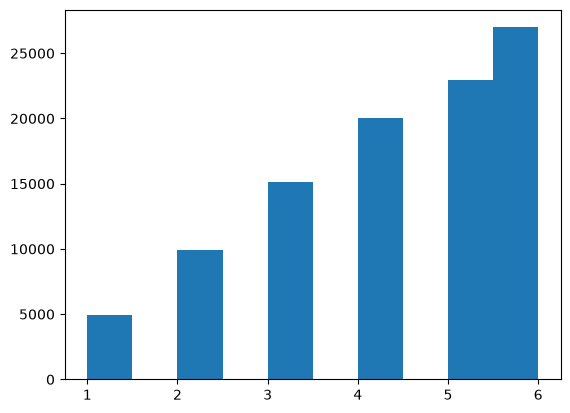

In [60]:
p = np.array([0.05,0.1,0.15,0.2,0.23,0.27])

F= np.cumsum(p)
alla_kast =[]

for i in range (100000):
    u = np.random.uniform(0, 1)
    alla_kast.append(np.sum(u>F)+1)

plt.hist(alla_kast)
plt.show()

Om vi har ett intervall mellan a och b, så kan vi skapa en täthetsfunktion på intervallet och integrera den för att få fördelningsfunktionen och på så sätt ge varje värde en procentuell chans.

När man sedan genererar ett slumptal mellan 0 och 1 kan det matchas mot fördelningsfunktionens y värden, för att utläsa ett x-värde vilket är slumptalets ekvivalten inom intervallet.
# Uppgift 3 | Monte Carlo
### a)

In [54]:
from python_functions import mc_conv
N_3_a = 1000, 10000, 100000, 1000000

def print_3_a(N, mu_3, err):
    print("N: ", N)
    print ("mu: ", mu_3)
    print ("err: ", err, "\n")

#1-D
print("1-D:\n")
for N in N_3_a:
    N_1D, mu_3, err = mc_conv(np.array([[ -5 , 5]]), N)
    print_3_a(N_1D, mu_3, err)

#2-D
for N in N_3_a:
    N_2D, mu_3, err = mc_conv(np.array([[ -5 , 5], [ -5 , 5]]), N)
    print_3_a(N_2D, mu_3, err)


1-D:

N:  1000
mu:  1.7761831645433963
err:  0.09398127470792025 

N:  10000
mu:  1.7784346685382544
err:  0.02823562358251594 

N:  100000
mu:  1.7731955042273915
err:  0.010474099285236368 

N:  1000000
mu:  1.772459978466253
err:  0.0025841234687450807 

N:  1000
mu:  3.0903225809181287
err:  0.3460005418056432 

N:  10000
mu:  3.1380521987873897
err:  0.10849661783962333 

N:  100000
mu:  3.1383705035454246
err:  0.02800515123374074 

N:  1000000
mu:  3.1391123051080636
err:  0.012567604488934297 



Desto högre mängd slumptal vi prövar, desto närmare det korrekta svaret kommer vi. Vi konvergerar mot korrekt area under funktionen.

### 1-D vs 2-D

1-D beräknas medelvärdet av alla värden från integralen, och det medelvärdet multipliceras sedan med intervallet för att få ut en area., medan den 2 dimensionella varianten istället beräknar volymen av samma funktion då två plan innefattas.
Då ett till intervall för en till dimension introduceras så får man en volym från de två intervallen.
Estimeringen som vi får från funktionen i 1-D är roten ur pi, vilket medför Pi för volymen, vilket stämmer överens med en kontrollberäkning.

## b)
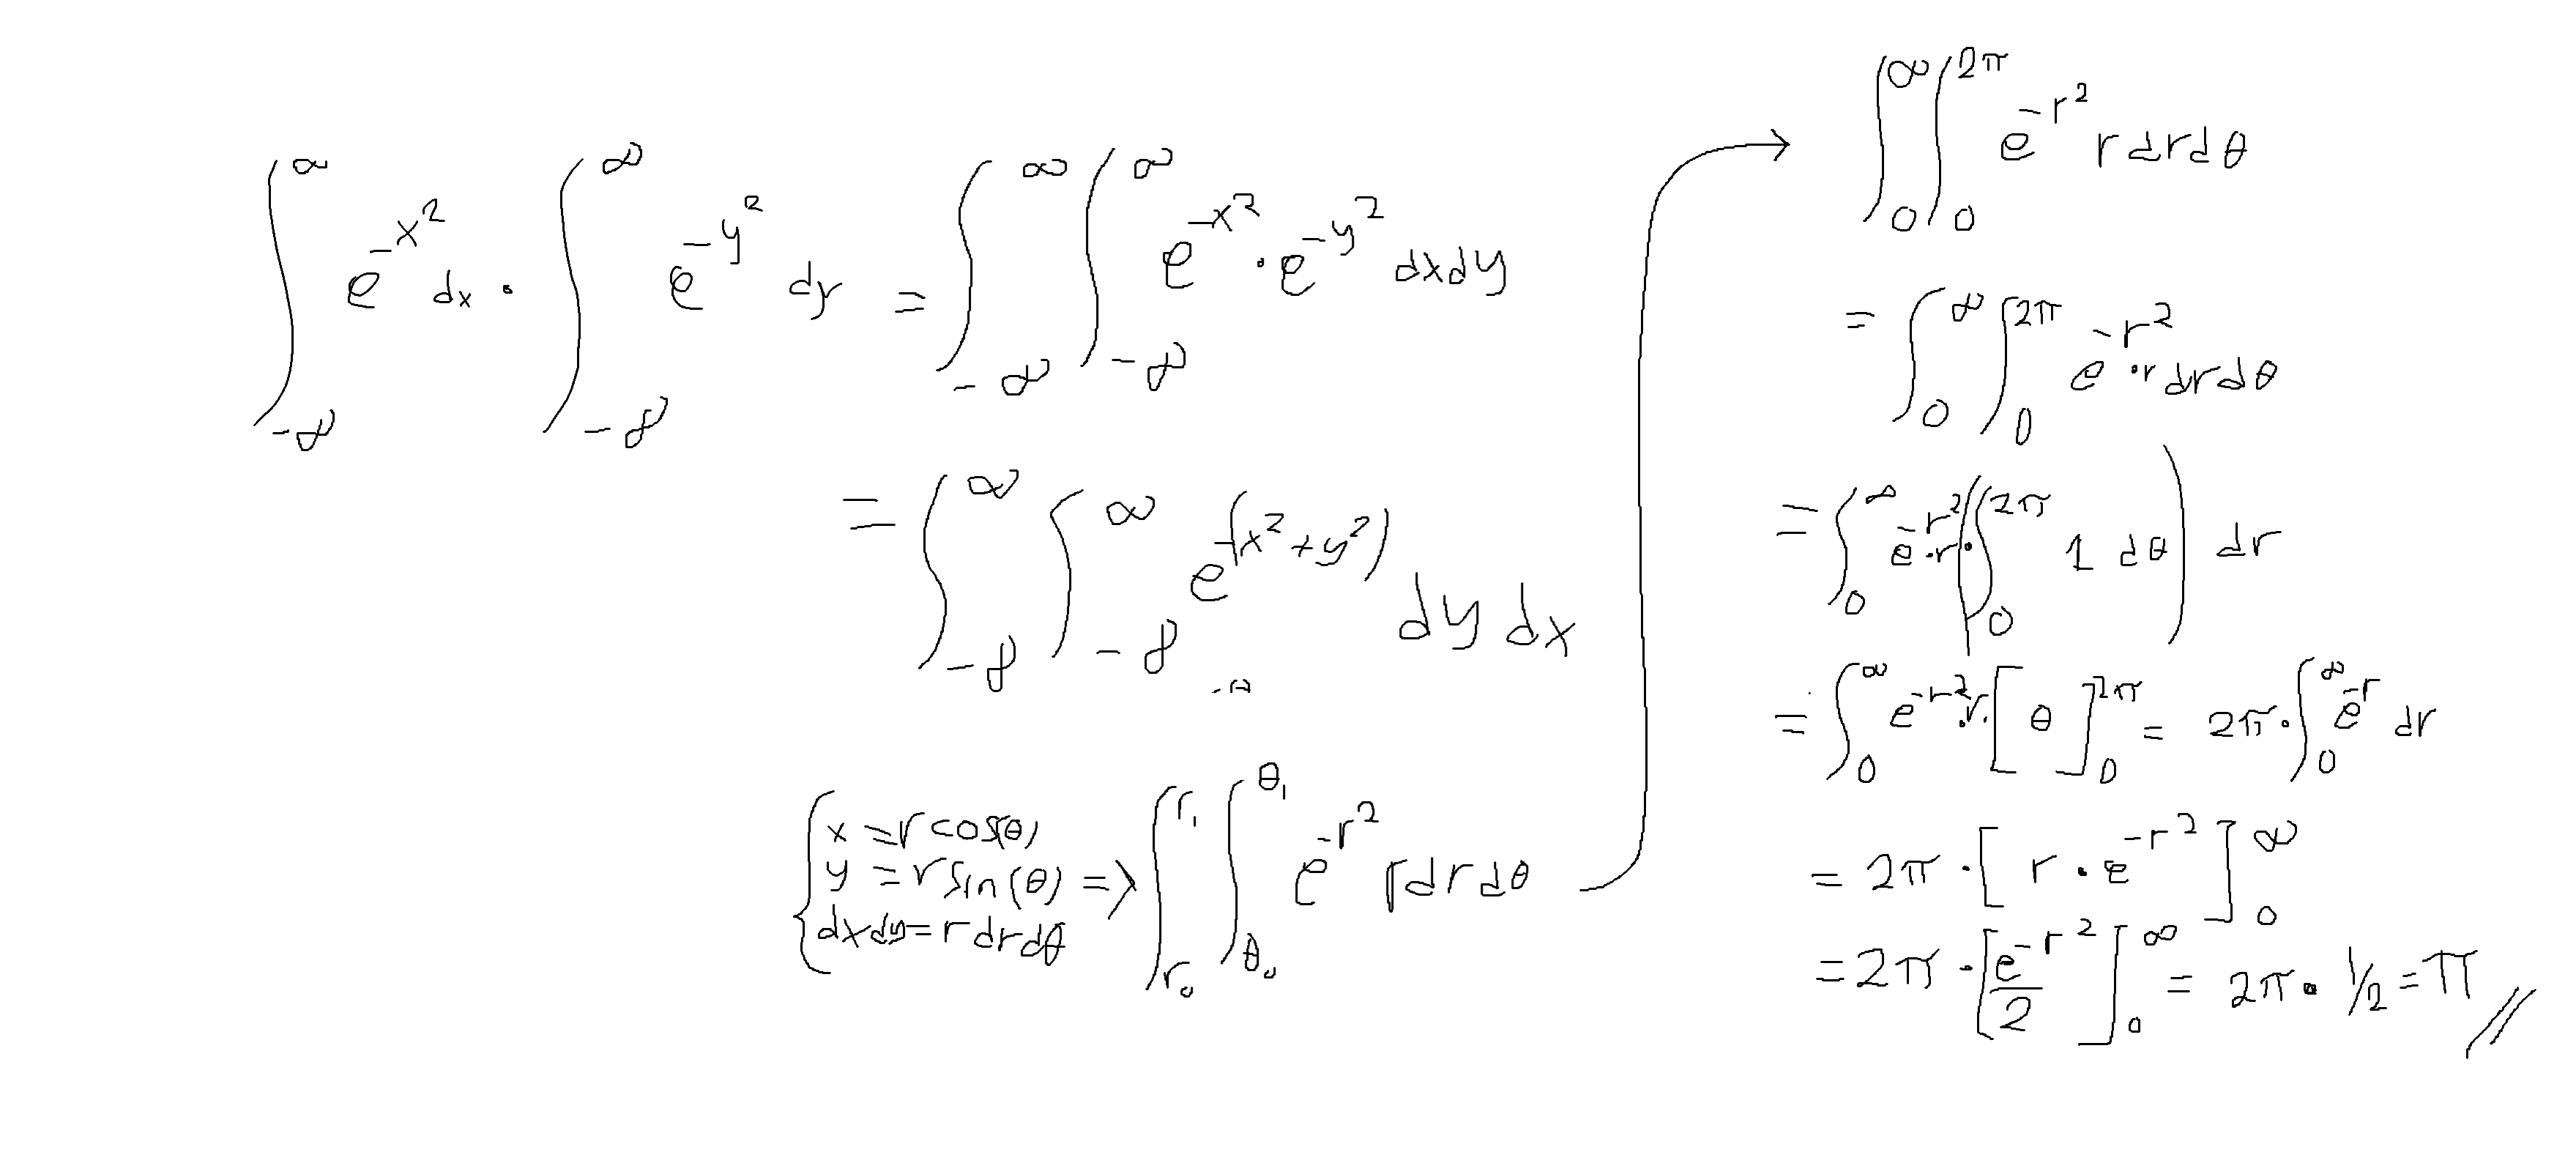
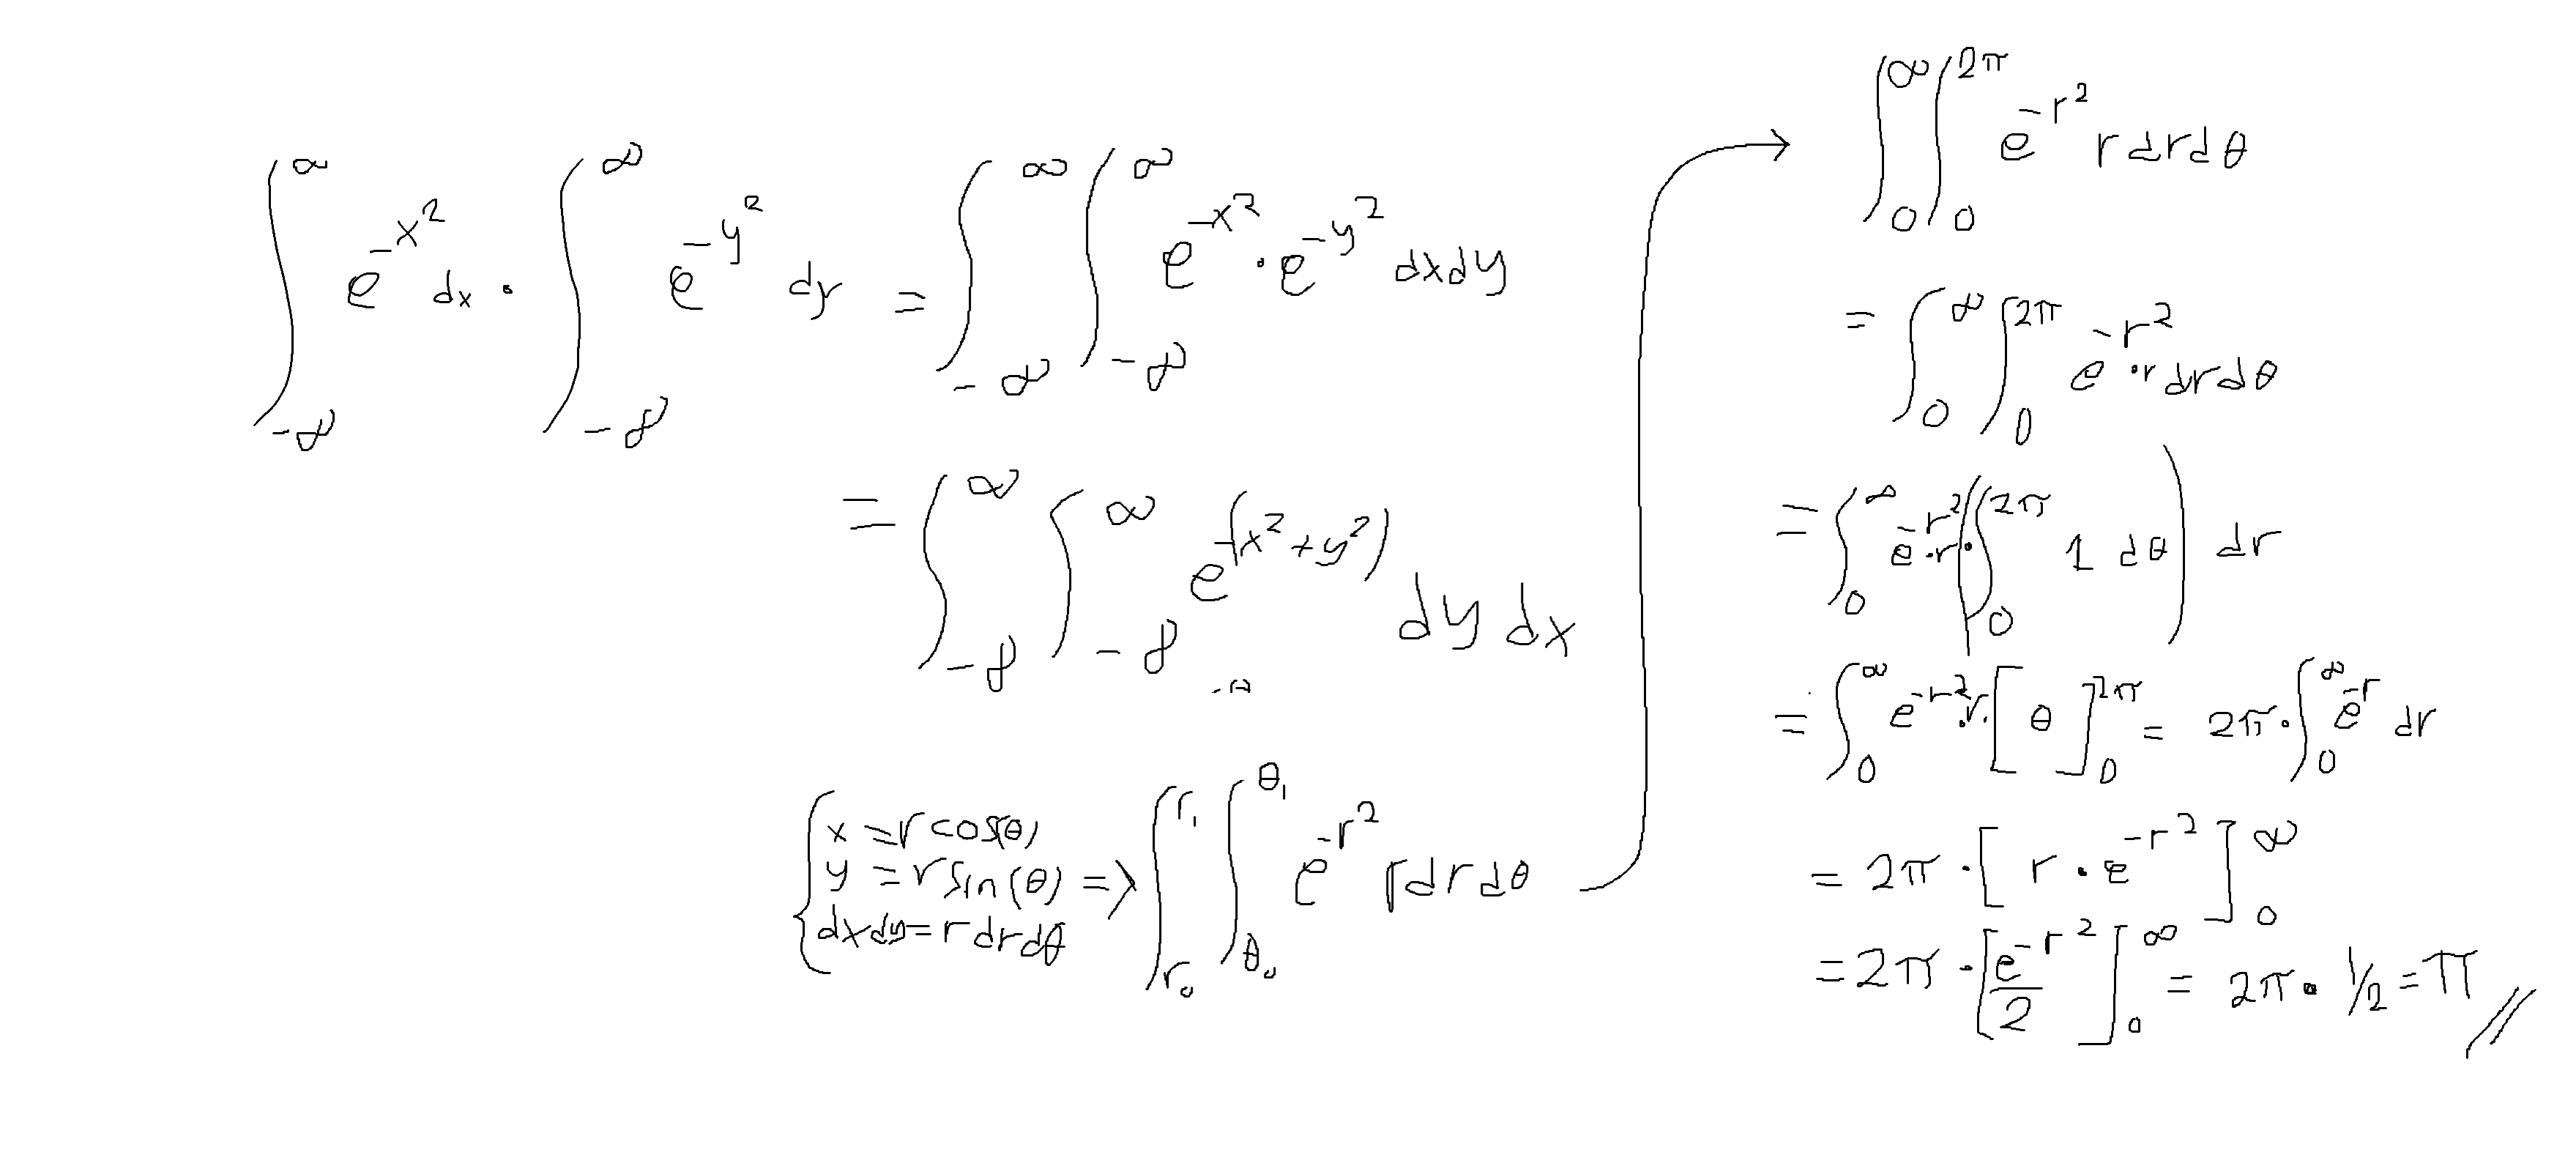

In [55]:
i = 6
dimensions = 6
mu = np.zeros(i)
err = np.zeros(i)
N = np.zeros(i)

for d in range (1, dimensions+1):
    to_insert = [-5,5]
    arr_arr = []
    for temp in range(d):
        arr_arr.append(to_insert)
    for j in range (i):
        N[j], mu[j], err[j] = mc_conv(np.array(arr_arr), 10 ** ( j + 1))
    a = np.polyfit(np.log(N), np.log(err), 1)
    print(d, "- D  p: ", a[0], " C: ", a[1])





1 - D  p:  -0.5035549767891978  C:  1.0991073594088612
2 - D  p:  -0.5021525879275548  C:  2.4701121511005324
3 - D  p:  -0.5028920430117854  C:  3.830770505273897
4 - D  p:  -0.5297215878470711  C:  5.367065148647733
5 - D  p:  -0.3433867903654179  C:  4.6759354339997685
6 - D  p:  0.04766958427141119  C:  1.5615009829679234


# Analys
p är densamma för båda, vilket ger 1/(roten ur N).

D blir däremot större för varje dimension, medan ökningen per steg inte är konsekvent, så innebär det att fler dimensioner ökar storleken på felet, nästan linärt.

## 3 c)
Felet ökar enligt N upphöjt till dimensionerna, exempelvis 5^1, 5^2, 5^3.
Detta medför att mängden tal ökar exponentiellt, och höga dimensioner blir drastiskt svårare att beräkna.

### Jämförelse
Monte Carlo är aldrig exakt då vi inte kan nyttja en oändlig mängd slumptal. Detta skiljer sig från trapetsmetoden som agerar mer som en vanlig beräkning. Däremot låter Monte Carlo oss estimera beräkningar i flera dimensioner utan att förhindras av den exponentiellt ökande mängd punkter som trapetsmetoden hade behövt.

# Uppgift 4

In [62]:
from python_functions import blackjack_sim
tot=0

for i in range(365):
    bs = blackjack_sim (100 , 10)
    tot += bs

print(tot)

-1075.0


Nej! Det lönar sig inte :(